In [25]:
# 2025.12.01 (지훈, 1번)

In [68]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [82]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle

import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import classification_report
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets        import make_classification
from sklearn.preprocessing   import RobustScaler

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import StackingClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.linear_model   import SGDClassifier
from sklearn.svm            import SVC
from sklearn.svm            import LinearSVC
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier


# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

import importlib

from utils import hyperopt_search
importlib.reload(hyperopt_search)


from utils import user_utils    as uu
importlib.reload(uu)
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [28]:
# -------------------------------------------------------
# 🔷 모델 생성 함수 (HyperOpt 파라미터 자동 적용)
# -------------------------------------------------------

def get_models():
    models = {
        "cat": CatBoostClassifier(**HP.cb_best_params),
        "gb": GradientBoostingClassifier(**HP.gb_best_params),
        "lgbm": LGBMClassifier(**HP.lgbm_best_param2),
        "lr": LogisticRegression(**HP.lr_best_params),
        "xgb": XGBClassifier(**HP.xgb_best_params, eval_metric='logloss'),
    }

    return models
# eof ----------------------------------------------------------------

In [29]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [30]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [31]:
# 2. 데이터 전처리
# 2.1 Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')
X_features.shape, y_target.shape

((284807, 29), (284807,))

In [32]:
# 2.2 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [33]:
# 2.3 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [34]:
# 2.4 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [ ]:
# ======================================
# 🔷 Stacking : CB + XGB + LGBM + GB
# ======================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold


# 1) 개별 모델 정의
models = get_models()  # 이미 HP.* 파라미터 적용된 모델 딕셔너리

cat_model = models["cat"]
xgb_model = models["xgb"]
lgbm_model = models["lgbm"]
gb_model  = models["gb"]

# 2) 스태킹 앙상블 구성
stacking_model = StackingClassifier(
    estimators=[
        ('cat', cat_model), 
        ('xgb', xgb_model), 
        ('lgbm', lgbm_model), 
        ('gb', gb_model)
    ],
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=23),
    n_jobs=-1
)

# 3) 학습
stacking_model.fit(X_tr, y_tr)

# 4) 예측
y_val_pred = stacking_model.predict(X_val)
y_val_proba = stacking_model.predict_proba(X_val)[:, 1]

# 5) 평가
print("Validation Report:")
print(classification_report(y_val, y_val_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))




[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W

In [43]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f"{'Stacking_best-HO'}_{timestamp}.pkl"
save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)  # 폴더 없으면 생성

# 전체 파일 경로
file_path = os.path.join(save_dir, filename)
        
with open(file_path, 'wb') as f:
            pickle.dump(stacking_model, f)

In [83]:
uu.get_clf_eval(
            y_val,
            y_val_pred,
            y_val_proba,
            model_name='cb+xgb+lgbm+gb_ho-best'
        )


folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.984, '정확도': 0.9903, '정밀도': 0.1407, '재현율': 0.8987, 'F1': 0.2434, 'F2': 0.4327, '오차행렬': [[90113, 867], [16, 142]]}


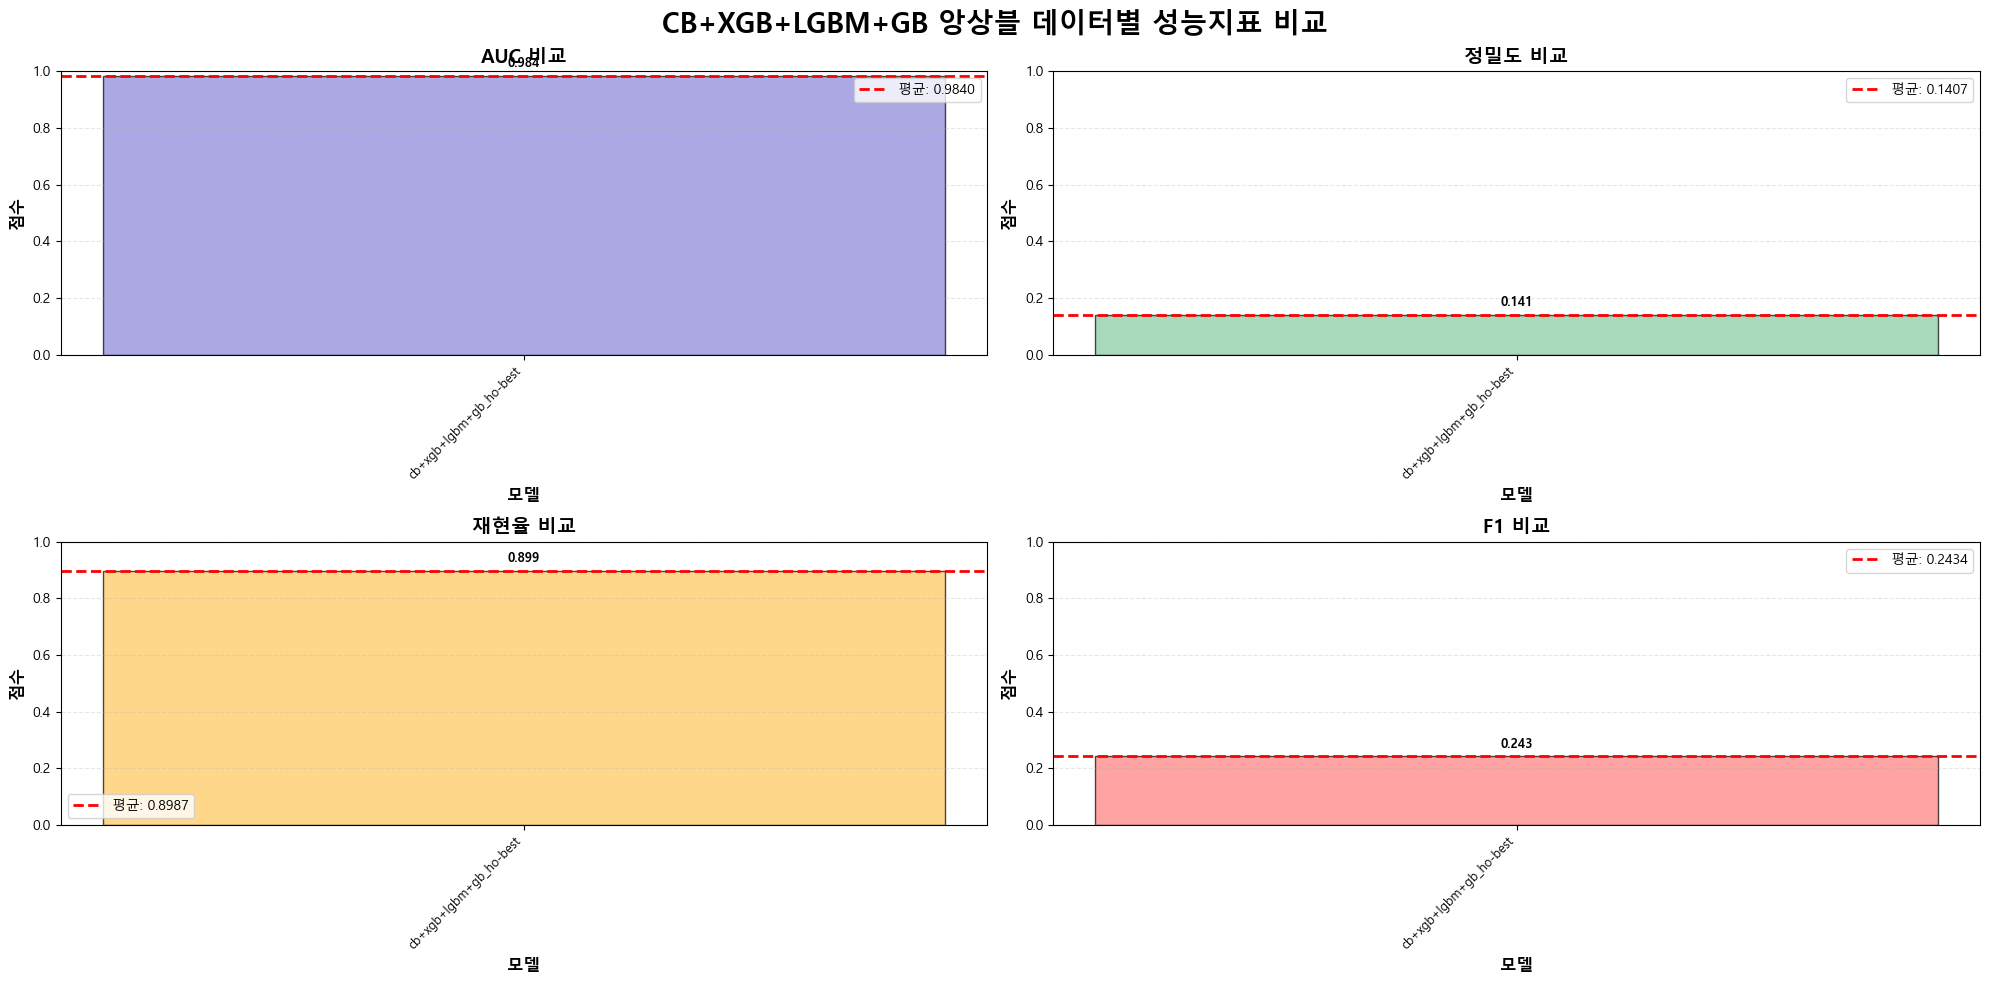


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9840 (cb+xgb+lgbm+gb_ho-best)
  최저: 0.9840 (cb+xgb+lgbm+gb_ho-best)
  평균: 0.9840
  표준편차: nan

[정밀도]
  최고: 0.1407 (cb+xgb+lgbm+gb_ho-best)
  최저: 0.1407 (cb+xgb+lgbm+gb_ho-best)
  평균: 0.1407
  표준편차: nan

[재현율]
  최고: 0.8987 (cb+xgb+lgbm+gb_ho-best)
  최저: 0.8987 (cb+xgb+lgbm+gb_ho-best)
  평균: 0.8987
  표준편차: nan

[F1]
  최고: 0.2434 (cb+xgb+lgbm+gb_ho-best)
  최저: 0.2434 (cb+xgb+lgbm+gb_ho-best)
  평균: 0.2434
  표준편차: nan


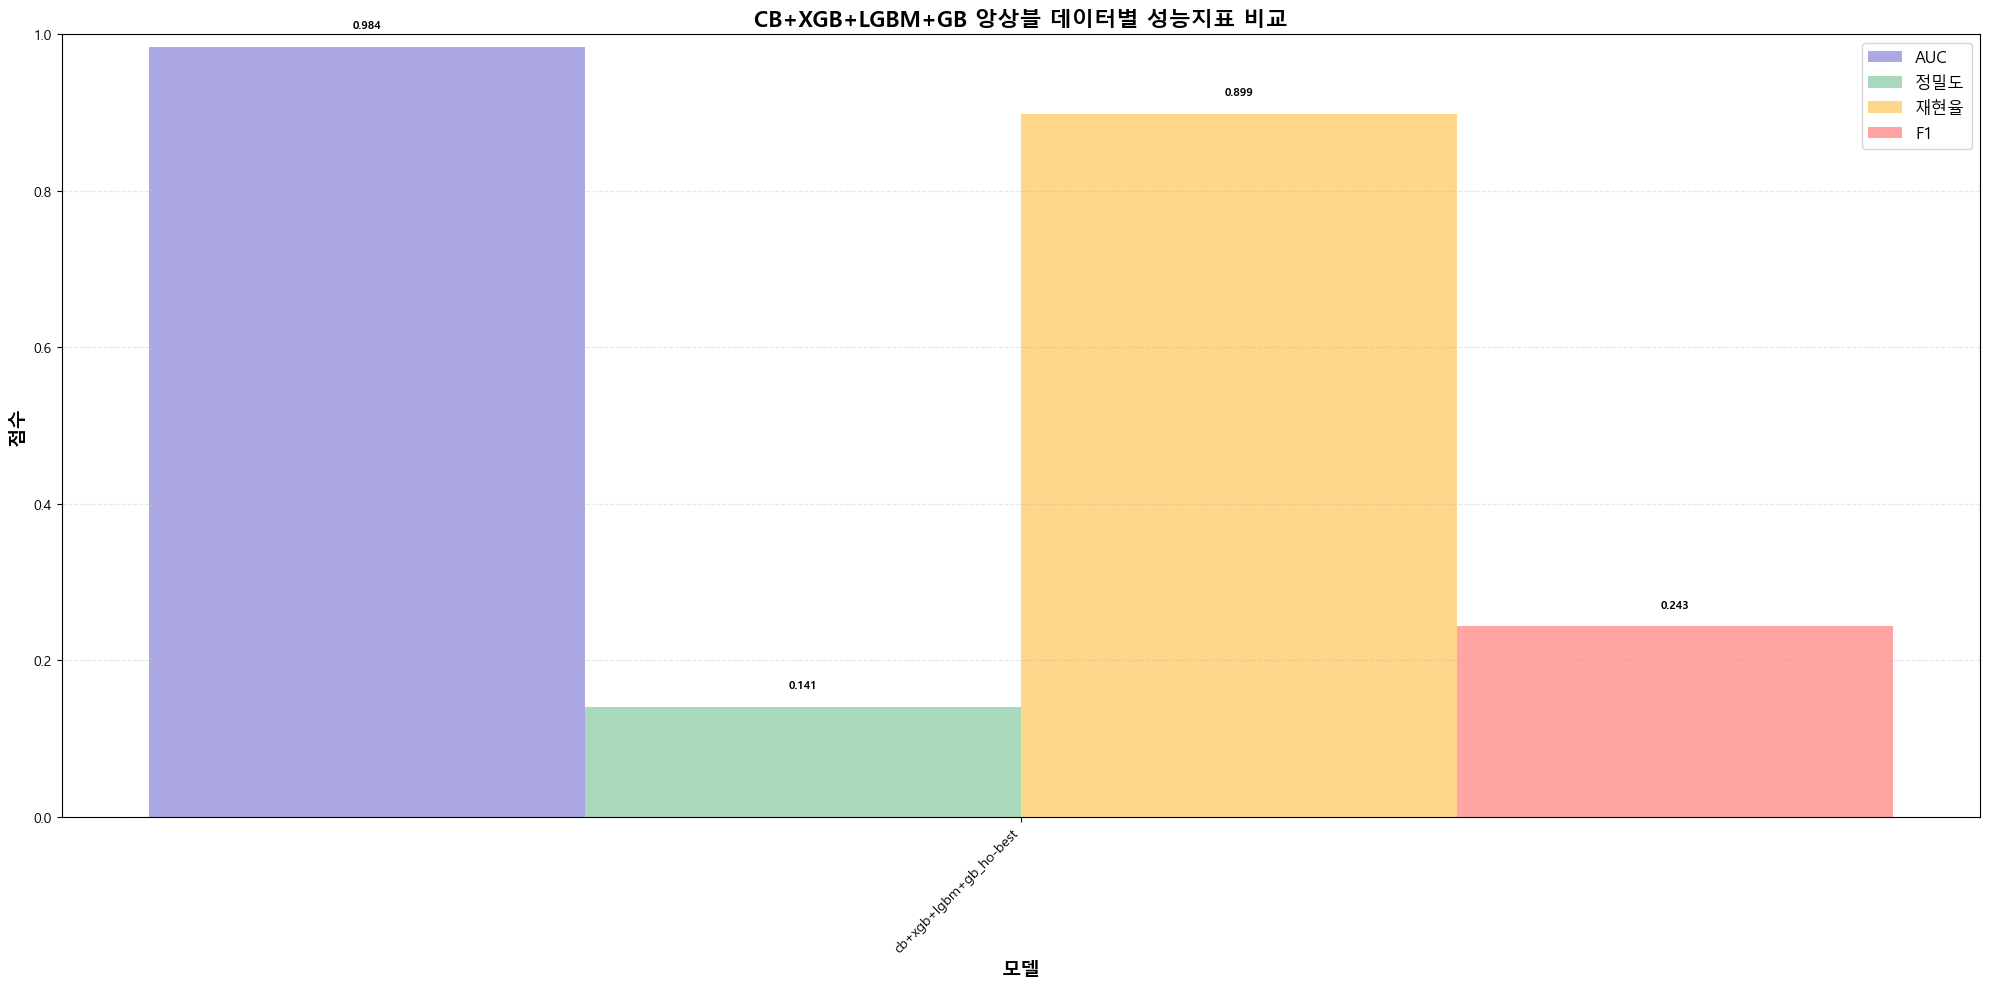


=== F1 Score 기준 상위 5개 모델 ===
[에러 발생] Column 'F1' has dtype object, cannot use method 'nlargest' with this dtype


In [90]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, fbeta_score, confusion_matrix
)

def get_clf_eval(y_true, y_pred, y_proba, model_name):
    """단일 모델 평가 결과 반환"""
    return {
        "AUC": round(roc_auc_score(y_true, y_proba), 4),
        "정확도": round(accuracy_score(y_true, y_pred), 4),
        "정밀도": round(precision_score(y_true, y_pred), 4),
        "재현율": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4),
        "F2": round(fbeta_score(y_true, y_pred, beta=2), 4),
        "오차행렬": confusion_matrix(y_true, y_pred).tolist()
    }

# -----------------------------------------
# 여러 모델 결과를 자동으로 모으는 부분
# -----------------------------------------

results = {}

# 예시: stacking 앙상블
results["cb+xgb+lgbm+gb_ho-best"] = get_clf_eval(
    y_val, y_val_pred, y_val_proba, "cb+xgb+lgbm+gb_ho-best"
)

# 만약 다른 모델도 평가했다면 추가
# results["catboost"] = get_clf_eval(y_val, cat_pred, cat_proba, "catboost")
# results["xgboost"] = get_clf_eval(y_val, xgb_pred, xgb_proba, "xgboost")
# results["lightgbm"] = get_clf_eval(y_val, lgbm_pred, lgbm_proba, "lightgbm")

# -----------------------------------------
# 그래프 함수 호출
# -----------------------------------------
mo.model_metrics_graph(results, "CB+XGB+LGBM+GB 앙상블 데이터별 성능지표 비교")

In [93]:
import numpy as np
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_proba, beta=1):
    """
    Precision-Recall Curve 기반으로 최적 threshold를 찾는 함수
    
    Parameters
    ----------
    y_true : array-like
        실제 타겟 값 (0/1)
    y_proba : array-like
        Positive class 확률 예측값
    beta : int, optional (default=1)
        F-beta 점수에서 beta 값 (beta=1 → F1, beta=2 → F2)
    
    Returns
    -------
    best_threshold : float
        최적 threshold 값
    best_score : float
        해당 threshold에서의 F-beta 점수
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # F-beta 점수 계산 (벡터 연산)
    fbeta_scores = (1 + beta**2) * (precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-10)

    best_idx = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_idx]
    best_score = fbeta_scores[best_idx]

    return best_threshold, best_score

In [ ]:
# F1 기준 최적 threshold
best_f1_threshold, best_f1_score = find_best_threshold(y_val, y_val_proba, beta=1)
print("Best F1 threshold:", round(best_f1_threshold, 4), "F1:", round(best_f1_score, 4))

# F2 기준 최적 threshold (Recall 강조)
best_f2_threshold, best_f2_score = find_best_threshold(y_val, y_val_proba, beta=2)
print("Best F2 threshold:", round(best_f2_threshold, 4), "F2:", round(best_f2_score, 4))

# 최적 threshold 적용
y_val_pred_opt = (y_val_proba >= best_f2_threshold).astype(int)

# Best F1 threshold: 0.9999 F1: 0.7368
# Best F2 threshold: 0.9999 F2: 0.7753

Best F1 threshold: 0.9999 F1: 0.7368
Best F2 threshold: 0.9999 F2: 0.7753
